In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!ls "/content/drive/MyDrive/lung_seg_data"

!mkdir -p /content/lung_data
!unzip -q "/content/drive/MyDrive/lung_seg_data/Montgomery.zip" -d /content/lung_data/montgomery
!unzip -q "/content/drive/MyDrive/lung_seg_data/Shenzhen.zip" -d /content/lung_data/shenzhen

!find /content/lung_data -maxdepth 3 -type d
!echo "---"
!cat "/content/drive/MyDrive/lung_seg_data/utils.py"

Mounted at /content/drive
lung_seg_data  Montgomery  Shenzhen  utils.py
unzip:  cannot find or open /content/drive/MyDrive/lung_seg_data/Montgomery.zip, /content/drive/MyDrive/lung_seg_data/Montgomery.zip.zip or /content/drive/MyDrive/lung_seg_data/Montgomery.zip.ZIP.
unzip:  cannot find or open /content/drive/MyDrive/lung_seg_data/Shenzhen.zip, /content/drive/MyDrive/lung_seg_data/Shenzhen.zip.zip or /content/drive/MyDrive/lung_seg_data/Shenzhen.zip.ZIP.
/content/lung_data
---
import io
import cv2
import zlib
import base64
import numpy as np


def mask_to_base64(mask: np.array):
    img_pil = Image.fromarray(np.array(mask, dtype=np.uint8))
    img_pil.putpalette([0, 0, 0, 255, 255, 255])
    bytes_io = io.BytesIO()
    img_pil.save(bytes_io, format="PNG", transparency=0, optimize=0)
    bytes = bytes_io.getvalue()
    return base64.b64encode(zlib.compress(bytes)).decode("utf-8")


def base64_to_image(s: str) -> np.ndarray:
    z = zlib.decompress(base64.b64decode(s))
    n = np.frombu

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!ls "/content/drive/MyDrive/lung_seg_data"
!echo "---"
!find "/content/drive/MyDrive/lung_seg_data" -maxdepth 3 -type d
!echo "---"
!cat "/content/drive/MyDrive/lung_seg_data/utils.py"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
lung_seg_data  Montgomery  Shenzhen  utils.py
---
/content/drive/MyDrive/lung_seg_data
/content/drive/MyDrive/lung_seg_data/Montgomery
/content/drive/MyDrive/lung_seg_data/Montgomery/img
/content/drive/MyDrive/lung_seg_data/Montgomery/ann
/content/drive/MyDrive/lung_seg_data/Montgomery/mask
/content/drive/MyDrive/lung_seg_data/Shenzhen
/content/drive/MyDrive/lung_seg_data/Shenzhen/ann
/content/drive/MyDrive/lung_seg_data/Shenzhen/img
/content/drive/MyDrive/lung_seg_data/Shenzhen/mask
---
import io
import cv2
import zlib
import base64
import numpy as np


def mask_to_base64(mask: np.array):
    img_pil = Image.fromarray(np.array(mask, dtype=np.uint8))
    img_pil.putpalette([0, 0, 0, 255, 255, 255])
    bytes_io = io.BytesIO()
    img_pil.save(bytes_io, format="PNG", transparency=0, optimize=0)
    bytes = bytes_io.getvalue()
    return base64.b64encode(zlib.c

In [ ]:
import os, cv2, numpy as np

base = "/content/drive/MyDrive/lung_seg_data"

for ds in ["Montgomery", "Shenzhen"]:
    imgs = sorted(os.listdir(f"{base}/{ds}/img"))
    masks = sorted(os.listdir(f"{base}/{ds}/mask"))
    print(f"--- {ds} ---")
    print("images:", len(imgs), "| masks:", len(masks))
    print("first 3 images:", imgs[:3])
    print("first 3 masks: ", masks[:3])

    img = cv2.imread(f"{base}/{ds}/img/{imgs[0]}", cv2.IMREAD_UNCHANGED)
    msk = cv2.imread(f"{base}/{ds}/mask/{masks[0]}", cv2.IMREAD_UNCHANGED)
    print("image shape:", img.shape, "| mask shape:", msk.shape)
    print("mask unique values:", np.unique(msk))

--- Montgomery ---
images: 138 | masks: 138
first 3 images: ['MCUCXR_0001_0.png', 'MCUCXR_0002_0.png', 'MCUCXR_0003_0.png']
first 3 masks:  ['MCUCXR_0001_0.png', 'MCUCXR_0002_0.png', 'MCUCXR_0003_0.png']
image shape: (512, 512, 3) | mask shape: (512, 512)
mask unique values: [  0   1   2   3   4   5   6   7   9  11  12  14  15  16  17  19  21  22
  23  25  26  27  29  30  33  37  38  39  40  41  42  43  44  45  46  47
  49  50  53  56  57  58  61  62  67  68  69  72  75  76  77  78  80  83
  84  86  87  89  90  93  95 103 104 105 106 107 108 111 112 113 117 123
 124 126 127 128 129 130 131 132 134 136 138 140 141 143 144 146 148 152
 153 154 157 158 160 162 163 164 166 168 170 173 174 175 177 178 180 181
 182 185 186 188 190 192 196 198 200 206 208 211 213 215 216 218 220 223
 225 227 228 229 231 236 238 239 240 241 243 244 245 246 247 248 250 251
 252 253 254 255]
--- Shenzhen ---
images: 566 | masks: 566
first 3 images: ['CHNCXR_0001_0.png', 'CHNCXR_0002_0.png', 'CHNCXR_0003_0.png']


Montgomery: lung fraction = 0.242 | in-between pixels = 0.0008
Shenzhen: lung fraction = 0.246 | in-between pixels = 0.0012


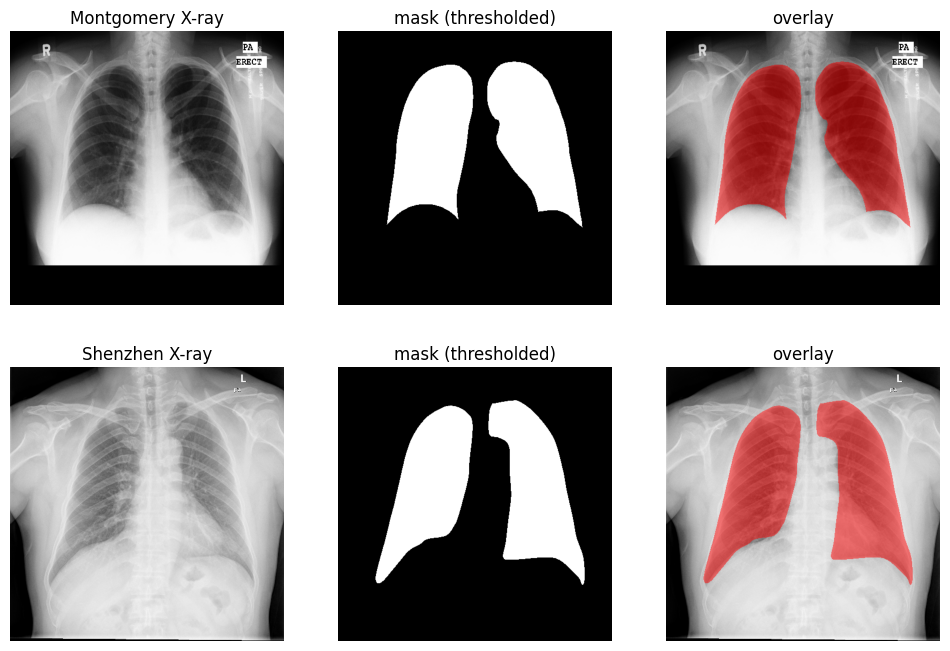

In [ ]:
import shutil, cv2, numpy as np, matplotlib.pyplot as plt

base = "/content/drive/MyDrive/lung_seg_data"
local = "/content/lung_data"

for ds in ["Montgomery", "Shenzhen"]:
    for sub in ["img", "mask"]:
        shutil.copytree(f"{base}/{ds}/{sub}", f"{local}/{ds}/{sub}", dirs_exist_ok=True)

samples = [("Montgomery", "MCUCXR_0001_0.png"), ("Shenzhen", "CHNCXR_0001_0.png")]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for row, (ds, name) in enumerate(samples):
    img = cv2.cvtColor(cv2.imread(f"{local}/{ds}/img/{name}"), cv2.COLOR_BGR2RGB)
    msk = cv2.imread(f"{local}/{ds}/mask/{name}", cv2.IMREAD_GRAYSCALE)
    binary = (msk > 127).astype(np.uint8)

    in_between = ((msk > 10) & (msk < 245)).mean()
    print(f"{ds}: lung fraction = {binary.mean():.3f} | in-between pixels = {in_between:.4f}")

    overlay = img.copy()
    overlay[binary == 1] = (0.5 * overlay[binary == 1] + 0.5 * np.array([255, 0, 0])).astype(np.uint8)

    axes[row, 0].imshow(img);                   axes[row, 0].set_title(f"{ds} X-ray")
    axes[row, 1].imshow(binary, cmap="gray");   axes[row, 1].set_title("mask (thresholded)")
    axes[row, 2].imshow(overlay);               axes[row, 2].set_title("overlay")

for ax in axes.ravel():
    ax.axis("off")
plt.show()

In [ ]:
import os
import random

import cv2
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

DATASETS = ["Montgomery", "Shenzhen"]


def find_pairs(root, datasets=DATASETS):
    """Return (image_path, mask_path, source) for every image that has a mask."""
    pairs = []
    for source in datasets:
        img_dir = os.path.join(root, source, "img")
        mask_dir = os.path.join(root, source, "mask")
        for name in sorted(os.listdir(img_dir)):
            mask_path = os.path.join(mask_dir, name)
            if os.path.exists(mask_path):
                pairs.append((os.path.join(img_dir, name), mask_path, source))
    return pairs


def split_pairs(pairs, val_frac=0.15, test_frac=0.15, seed=42):
    """Split into train, val and test, keeping the Montgomery/Shenzhen ratio in each."""
    sources = [p[2] for p in pairs]
    train_val, test = train_test_split(
        pairs, test_size=test_frac, random_state=seed, stratify=sources
    )
    tv_sources = [p[2] for p in train_val]
    rel_val = val_frac / (1 - test_frac)
    train, val = train_test_split(
        train_val, test_size=rel_val, random_state=seed, stratify=tv_sources
    )
    return train, val, test


def augment(image, mask):
    """Same small rotation and scale on image and mask, brightness and contrast on image only."""
    size = image.shape[0]
    angle = random.uniform(-10, 10)
    scale = random.uniform(0.9, 1.1)
    matrix = cv2.getRotationMatrix2D((size / 2, size / 2), angle, scale)
    image = cv2.warpAffine(image, matrix, (size, size), flags=cv2.INTER_LINEAR,
                           borderMode=cv2.BORDER_CONSTANT, borderValue=0)
    mask = cv2.warpAffine(mask, matrix, (size, size), flags=cv2.INTER_NEAREST,
                          borderMode=cv2.BORDER_CONSTANT, borderValue=0)

    contrast = random.uniform(0.85, 1.15)
    brightness = random.uniform(-0.1, 0.1)
    image = np.clip(image * contrast + brightness, 0.0, 1.0)
    return image.astype(np.float32), mask


class LungDataset(Dataset):
    """Chest X-ray images paired with binary lung masks."""

    def __init__(self, pairs, img_size=256, augment=False):
        self.pairs = pairs
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path, _ = self.pairs[idx]
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        mask = (mask > 127).astype(np.uint8)
        size = (self.img_size, self.img_size)
        image = cv2.resize(image, size, interpolation=cv2.INTER_AREA)
        mask = cv2.resize(mask, size, interpolation=cv2.INTER_NEAREST)

        image = image.astype(np.float32) / 255.0
        mask = mask.astype(np.float32)

        if self.augment:
            image, mask = augment(image, mask)

        return torch.from_numpy(image).unsqueeze(0), torch.from_numpy(mask).unsqueeze(0)


def get_dataloaders(root, img_size=256, batch_size=8, seed=42, num_workers=2):
    """Build train, validation and test loaders. Only the training set is augmented."""
    pairs = find_pairs(root)
    train_pairs, val_pairs, test_pairs = split_pairs(pairs, seed=seed)

    train_ds = LungDataset(train_pairs, img_size, augment=True)
    val_ds = LungDataset(val_pairs, img_size)
    test_ds = LungDataset(test_pairs, img_size)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, val_loader, test_loader

In [ ]:
root = "/content/lung_data"
train_loader, val_loader, test_loader = get_dataloaders(root)

print("train / val / test:", len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset))

images, masks = next(iter(train_loader))
print("batch shapes:", images.shape, masks.shape)
print("image range:", images.min().item(), images.max().item())
print("mask values:", torch.unique(masks))

paths = lambda loader: {p[0] for p in loader.dataset.pairs}
tr, va, te = paths(train_loader), paths(val_loader), paths(test_loader)
print("overlap train/val, train/test, val/test:", len(tr & va), len(tr & te), len(va & te))

train / val / test: 492 106 106
batch shapes: torch.Size([8, 1, 256, 256]) torch.Size([8, 1, 256, 256])
image range: 0.0 1.0
mask values: tensor([0., 1.])
overlap train/val, train/test, val/test: 0 0 0


In [ ]:
import torch
import torch.nn as nn


class DoubleConv(nn.Module):
    """Two 3x3 convolutions, each followed by batch norm and ReLU."""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """U-Net for binary segmentation. Returns raw logits, one per pixel."""

    def __init__(self, in_channels=1, out_channels=1, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, base)
        self.enc2 = DoubleConv(base, base * 2)
        self.enc3 = DoubleConv(base * 2, base * 4)
        self.enc4 = DoubleConv(base * 4, base * 8)
        self.bottleneck = DoubleConv(base * 8, base * 16)

        self.pool = nn.MaxPool2d(2)

        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2)
        self.dec4 = DoubleConv(base * 16, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)

        self.out = nn.Conv2d(base, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1)


class DiceBCELoss(nn.Module):
    """Binary cross-entropy plus Dice loss, computed on raw logits."""

    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce = self.bce(logits, targets)
        probs = torch.sigmoid(logits).flatten(1)
        targets = targets.flatten(1)
        intersection = (probs * targets).sum(dim=1)
        dice = (2 * intersection + self.smooth) / (
            probs.sum(dim=1) + targets.sum(dim=1) + self.smooth
        )
        return bce + (1 - dice.mean())


def dice_score(logits, targets, threshold=0.5, eps=1e-7):
    """Mean Dice score over the images in a batch."""
    preds = (torch.sigmoid(logits) > threshold).float().flatten(1)
    targets = targets.flatten(1)
    inter = (preds * targets).sum(dim=1)
    return ((2 * inter + eps) / (preds.sum(dim=1) + targets.sum(dim=1) + eps)).mean().item()


def iou_score(logits, targets, threshold=0.5, eps=1e-7):
    """Mean intersection over union over the images in a batch."""
    preds = (torch.sigmoid(logits) > threshold).float().flatten(1)
    targets = targets.flatten(1)
    inter = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - inter
    return ((inter + eps) / (union + eps)).mean().item()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = UNet().to(device)
print("Parameters:", sum(p.numel() for p in model.parameters()))

images, masks = next(iter(train_loader))
images, masks = images.to(device), masks.to(device)
logits = model(images)
print("output shape:", logits.shape)

criterion = DiceBCELoss()
print("loss (untrained):", criterion(logits, masks).item())
print("dice (untrained):", dice_score(logits, masks))

# A perfect prediction must score 1.0 on both metrics
perfect = masks * 20 - 10
print("perfect prediction -> dice:", dice_score(perfect, masks), "| iou:", iou_score(perfect, masks))

Using device: cuda
Parameters: 7762465
output shape: torch.Size([8, 1, 256, 256])
loss (untrained): 1.347129225730896
dice (untrained): 0.3184066414833069
perfect prediction -> dice: 1.0 | iou: 1.0


Epoch 1/40 | lr 1e-03 | Train loss 0.8046, Dice 0.8170 | Val loss 0.5879, Dice 0.8998, IoU 0.8232  <- best
Epoch 2/40 | lr 1e-03 | Train loss 0.4805, Dice 0.9356 | Val loss 0.4330, Dice 0.9488, IoU 0.9033  <- best
Epoch 3/40 | lr 1e-03 | Train loss 0.3311, Dice 0.9466 | Val loss 0.2839, Dice 0.9570, IoU 0.9182  <- best
Epoch 4/40 | lr 1e-03 | Train loss 0.2519, Dice 0.9477 | Val loss 0.2139, Dice 0.9570, IoU 0.9185
Epoch 5/40 | lr 1e-03 | Train loss 0.1944, Dice 0.9546 | Val loss 0.1897, Dice 0.9531, IoU 0.9116
Epoch 6/40 | lr 1e-03 | Train loss 0.1623, Dice 0.9575 | Val loss 0.1461, Dice 0.9611, IoU 0.9260  <- best
Epoch 7/40 | lr 1e-03 | Train loss 0.1573, Dice 0.9539 | Val loss 0.1698, Dice 0.9482, IoU 0.9029
Epoch 8/40 | lr 1e-03 | Train loss 0.1549, Dice 0.9516 | Val loss 0.1313, Dice 0.9589, IoU 0.9222
Epoch 9/40 | lr 1e-03 | Train loss 0.1339, Dice 0.9576 | Val loss 0.1199, Dice 0.9615, IoU 0.9266  <- best
Epoch 10/40 | lr 1e-03 | Train loss 0.1278, Dice 0.9584 | Val loss 0.1101

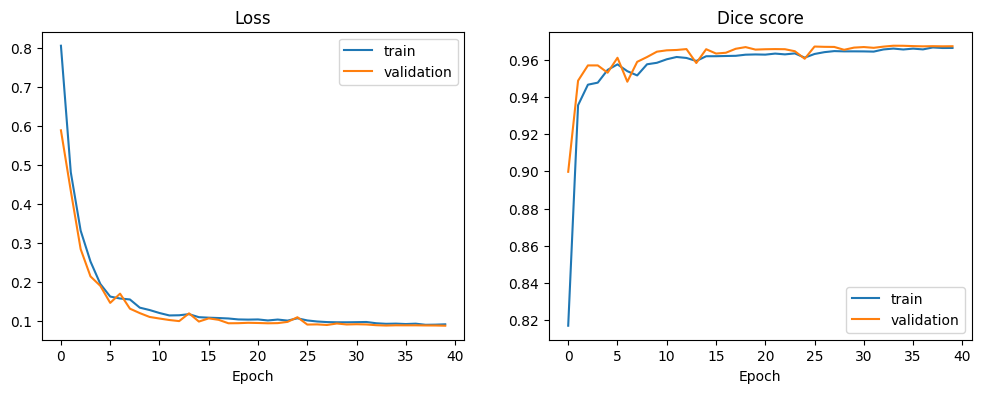

'/content/drive/MyDrive/lung_seg_data/best_unet.pt'

In [ ]:
import shutil
import torch
import matplotlib.pyplot as plt


def run_epoch(model, loader, criterion, device, optimizer=None):
    """One pass over a loader. Trains if an optimizer is given, otherwise evaluates."""
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = total_dice = total_iou = 0.0
    count = 0

    with torch.set_grad_enabled(training):
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            logits = model(images)
            loss = criterion(logits, masks)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            n = images.size(0)
            total_loss += loss.item() * n
            total_dice += dice_score(logits.detach(), masks) * n
            total_iou += iou_score(logits.detach(), masks) * n
            count += n

    return total_loss / count, total_dice / count, total_iou / count


def train_model(model, train_loader, val_loader, device, num_epochs=40, lr=1e-3,
                checkpoint_path="best_unet.pt"):
    """Train the model, keep the checkpoint with the best validation Dice."""
    criterion = DiceBCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=5
    )

    history = {"train_loss": [], "val_loss": [], "train_dice": [], "val_dice": []}
    best_val_dice = 0.0

    for epoch in range(num_epochs):
        tr_loss, tr_dice, _ = run_epoch(model, train_loader, criterion, device, optimizer)
        va_loss, va_dice, va_iou = run_epoch(model, val_loader, criterion, device)
        scheduler.step(va_dice)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_dice"].append(tr_dice)
        history["val_dice"].append(va_dice)

        line = (f"Epoch {epoch+1}/{num_epochs} | lr {optimizer.param_groups[0]['lr']:.0e} | "
                f"Train loss {tr_loss:.4f}, Dice {tr_dice:.4f} | "
                f"Val loss {va_loss:.4f}, Dice {va_dice:.4f}, IoU {va_iou:.4f}")

        if va_dice > best_val_dice:
            best_val_dice = va_dice
            torch.save(model.state_dict(), checkpoint_path)
            line += "  <- best"
        print(line)

    return history, best_val_dice


def plot_training_curves(history, save_path="training_curves.png"):
    """Plot loss and Dice for train and validation sets."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["val_loss"], label="validation")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[1].plot(history["train_dice"], label="train")
    axes[1].plot(history["val_dice"], label="validation")
    axes[1].set_title("Dice score")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()


torch.manual_seed(42)
model = UNet().to(device)
history, best_val_dice = train_model(model, train_loader, val_loader, device)
print("Best validation Dice:", best_val_dice)

plot_training_curves(history)

# Colab's local disk is wiped when the session ends, so keep a copy in Drive
shutil.copy("best_unet.pt", "/content/drive/MyDrive/lung_seg_data/best_unet.pt")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
base = "/content/drive/MyDrive/lung_seg_data"
local = "/content/lung_data"
for ds in ["Montgomery", "Shenzhen"]:
    for sub in ["img", "mask"]:
        shutil.copytree(f"{base}/{ds}/{sub}", f"{local}/{ds}/{sub}", dirs_exist_ok=True)

print("weights in Drive:", os.path.exists(f"{base}/best_unet.pt"))

Mounted at /content/drive
weights in Drive: True


In [ ]:
import os
import random

import cv2
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

DATASETS = ["Montgomery", "Shenzhen"]


def find_pairs(root, datasets=DATASETS):
    """Return (image_path, mask_path, source) for every image that has a mask."""
    pairs = []
    for source in datasets:
        img_dir = os.path.join(root, source, "img")
        mask_dir = os.path.join(root, source, "mask")
        for name in sorted(os.listdir(img_dir)):
            mask_path = os.path.join(mask_dir, name)
            if os.path.exists(mask_path):
                pairs.append((os.path.join(img_dir, name), mask_path, source))
    return pairs


def split_pairs(pairs, val_frac=0.15, test_frac=0.15, seed=42):
    """Split into train, val and test, keeping the Montgomery/Shenzhen ratio in each."""
    sources = [p[2] for p in pairs]
    train_val, test = train_test_split(
        pairs, test_size=test_frac, random_state=seed, stratify=sources
    )
    tv_sources = [p[2] for p in train_val]
    rel_val = val_frac / (1 - test_frac)
    train, val = train_test_split(
        train_val, test_size=rel_val, random_state=seed, stratify=tv_sources
    )
    return train, val, test


def augment(image, mask):
    """Same small rotation and scale on image and mask, brightness and contrast on image only."""
    size = image.shape[0]
    angle = random.uniform(-10, 10)
    scale = random.uniform(0.9, 1.1)
    matrix = cv2.getRotationMatrix2D((size / 2, size / 2), angle, scale)
    image = cv2.warpAffine(image, matrix, (size, size), flags=cv2.INTER_LINEAR,
                           borderMode=cv2.BORDER_CONSTANT, borderValue=0)
    mask = cv2.warpAffine(mask, matrix, (size, size), flags=cv2.INTER_NEAREST,
                          borderMode=cv2.BORDER_CONSTANT, borderValue=0)

    contrast = random.uniform(0.85, 1.15)
    brightness = random.uniform(-0.1, 0.1)
    image = np.clip(image * contrast + brightness, 0.0, 1.0)
    return image.astype(np.float32), mask


class LungDataset(Dataset):
    """Chest X-ray images paired with binary lung masks."""

    def __init__(self, pairs, img_size=256, augment=False):
        self.pairs = pairs
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path, _ = self.pairs[idx]
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        mask = (mask > 127).astype(np.uint8)
        size = (self.img_size, self.img_size)
        image = cv2.resize(image, size, interpolation=cv2.INTER_AREA)
        mask = cv2.resize(mask, size, interpolation=cv2.INTER_NEAREST)

        image = image.astype(np.float32) / 255.0
        mask = mask.astype(np.float32)

        if self.augment:
            image, mask = augment(image, mask)

        return torch.from_numpy(image).unsqueeze(0), torch.from_numpy(mask).unsqueeze(0)


def get_dataloaders(root, img_size=256, batch_size=8, seed=42, num_workers=2):
    """Build train, validation and test loaders. Only the training set is augmented."""
    pairs = find_pairs(root)
    train_pairs, val_pairs, test_pairs = split_pairs(pairs, seed=seed)

    train_ds = LungDataset(train_pairs, img_size, augment=True)
    val_ds = LungDataset(val_pairs, img_size)
    test_ds = LungDataset(test_pairs, img_size)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, val_loader, test_loader

In [ ]:
import torch
import torch.nn as nn


class DoubleConv(nn.Module):
    """Two 3x3 convolutions, each followed by batch norm and ReLU."""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """U-Net for binary segmentation. Returns raw logits, one per pixel."""

    def __init__(self, in_channels=1, out_channels=1, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, base)
        self.enc2 = DoubleConv(base, base * 2)
        self.enc3 = DoubleConv(base * 2, base * 4)
        self.enc4 = DoubleConv(base * 4, base * 8)
        self.bottleneck = DoubleConv(base * 8, base * 16)

        self.pool = nn.MaxPool2d(2)

        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2)
        self.dec4 = DoubleConv(base * 16, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)

        self.out = nn.Conv2d(base, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1)


class DiceBCELoss(nn.Module):
    """Binary cross-entropy plus Dice loss, computed on raw logits."""

    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce = self.bce(logits, targets)
        probs = torch.sigmoid(logits).flatten(1)
        targets = targets.flatten(1)
        intersection = (probs * targets).sum(dim=1)
        dice = (2 * intersection + self.smooth) / (
            probs.sum(dim=1) + targets.sum(dim=1) + self.smooth
        )
        return bce + (1 - dice.mean())


def dice_score(logits, targets, threshold=0.5, eps=1e-7):
    """Mean Dice score over the images in a batch."""
    preds = (torch.sigmoid(logits) > threshold).float().flatten(1)
    targets = targets.flatten(1)
    inter = (preds * targets).sum(dim=1)
    return ((2 * inter + eps) / (preds.sum(dim=1) + targets.sum(dim=1) + eps)).mean().item()


def iou_score(logits, targets, threshold=0.5, eps=1e-7):
    """Mean intersection over union over the images in a batch."""
    preds = (torch.sigmoid(logits) > threshold).float().flatten(1)
    targets = targets.flatten(1)
    inter = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - inter
    return ((inter + eps) / (union + eps)).mean().item()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

train_loader, val_loader, test_loader = get_dataloaders("/content/lung_data")
print(len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset))

model = UNet().to(device)
shutil.copy(f"{base}/best_unet.pt", "best_unet.pt")

Using device: cuda
492 106 106


'best_unet.pt'

TEST (n=106)  Dice 0.9615 +/- 0.0332 | IoU 0.9276 +/- 0.0573
  Montgomery  n=21  Dice 0.9765 | IoU 0.9545 | worst Dice 0.9263
  Shenzhen    n=85  Dice 0.9578 | IoU 0.9210 | worst Dice 0.8024


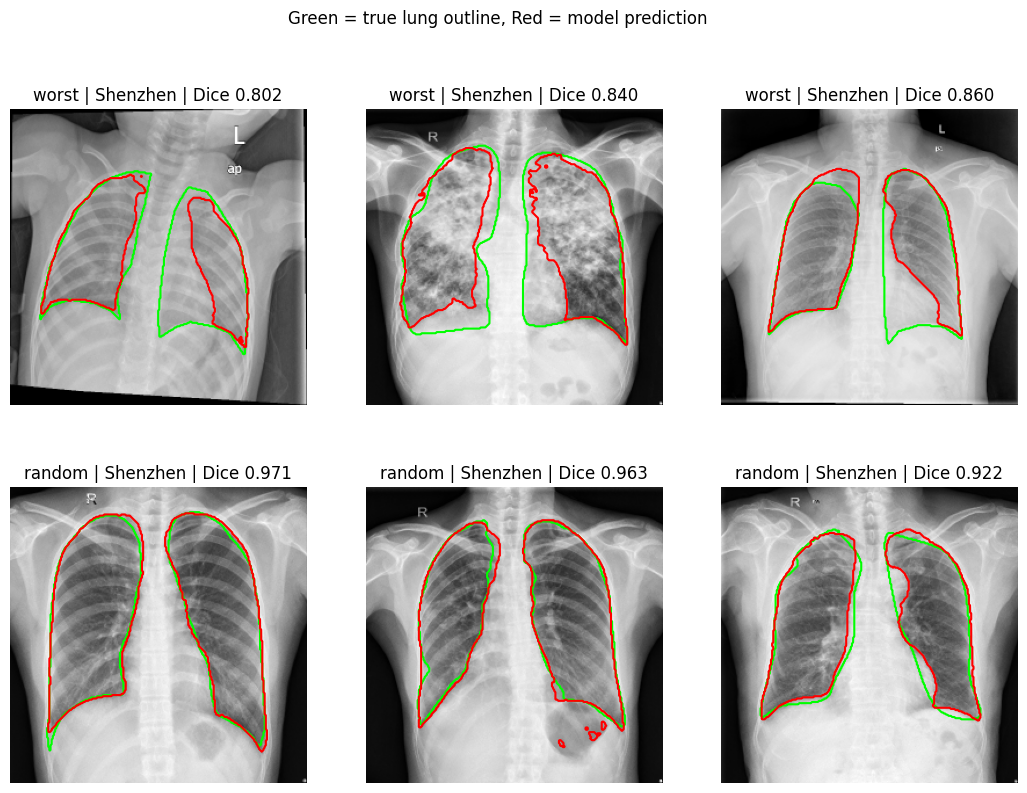

'/content/drive/MyDrive/lung_seg_data/test_predictions.png'

In [ ]:
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt

model.load_state_dict(torch.load("best_unet.pt", map_location=device))
model.eval()

test_ds = test_loader.dataset
rows = []
predictions = {}

with torch.no_grad():
    for i in range(len(test_ds)):
        image, mask = test_ds[i]
        logits = model(image.unsqueeze(0).to(device))
        mask_b = mask.unsqueeze(0).to(device)
        d = dice_score(logits, mask_b)
        j = iou_score(logits, mask_b)
        pred = (torch.sigmoid(logits) > 0.5).float().cpu().squeeze().numpy()
        predictions[i] = pred
        rows.append((i, test_ds.pairs[i][2], d, j))

dice_all = np.array([r[2] for r in rows])
iou_all = np.array([r[3] for r in rows])
print(f"TEST (n={len(rows)})  Dice {dice_all.mean():.4f} +/- {dice_all.std():.4f} | IoU {iou_all.mean():.4f} +/- {iou_all.std():.4f}")

for source in ["Montgomery", "Shenzhen"]:
    d = np.array([r[2] for r in rows if r[1] == source])
    j = np.array([r[3] for r in rows if r[1] == source])
    print(f"  {source:<11} n={len(d):<3} Dice {d.mean():.4f} | IoU {j.mean():.4f} | worst Dice {d.min():.4f}")

order = np.argsort(dice_all)
worst = list(order[:3])
random.seed(0)
rand = random.sample([i for i in range(len(rows)) if i not in worst], 3)
chosen = worst + rand
labels = ["worst"] * 3 + ["random"] * 3

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, idx, label in zip(axes.ravel(), chosen, labels):
    image, mask = test_ds[idx]
    ax.imshow(image.squeeze().numpy(), cmap="gray")
    ax.contour(mask.squeeze().numpy(), levels=[0.5], colors="lime", linewidths=1.5)
    ax.contour(predictions[idx], levels=[0.5], colors="red", linewidths=1.5)
    ax.set_title(f"{label} | {rows[idx][1]} | Dice {rows[idx][2]:.3f}")
    ax.axis("off")
plt.suptitle("Green = true lung outline, Red = model prediction")
plt.savefig("test_predictions.png", bbox_inches="tight")
plt.show()

shutil.copy("test_predictions.png", f"{base}/test_predictions.png")

In [ ]:
%cd /content
!rm -rf lung-segmentation-unet
!git clone https://github.com/paulblessingjeremiah-ai/lung-segmentation-unet.git
%cd lung-segmentation-unet
!pip install -r requirements.txt -q
!pytest tests/ -v

/content
Cloning into 'lung-segmentation-unet'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 50 (delta 14), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (50/50), 19.17 KiB | 1.74 MiB/s, done.
Resolving deltas: 100% (14/14), done.
/content/lung-segmentation-unet
============================= test session starts ==============================
platform linux -- Python 3.13.15, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/lung-segmentation-unet
plugins: typeguard-4.6.0, platformdirs-4.12.2, anyio-4.15.1, langsmith-0.14.2
collected 9 items                                                              

tests/test_data.py::test_find_pairs_matches_each_image_with_its_mask PASSED [ 11%]
tests/test_data.py::test_split_has_no_overlap_and_keeps_every_image PASSED [ 22%]
tests/test_data.py::test_dataset_item_shapes_and_value_range

In [ ]:
%cd /content
!rm -rf lung-segmentation-unet
!git clone -q https://github.com/paulblessingjeremiah-ai/lung-segmentation-unet.git
%cd lung-segmentation-unet
!pip install -q -r requirements.txt

import os, sys, shutil, torch
sys.path.insert(0, "src")

from google.colab import drive
drive.mount('/content/drive')
base = "/content/drive/MyDrive/lung_seg_data"
for ds in ["Montgomery", "Shenzhen"]:
    for sub in ["img", "mask"]:
        shutil.copytree(f"{base}/{ds}/{sub}", f"/content/lung_data/{ds}/{sub}", dirs_exist_ok=True)

from lung_seg.data import get_dataloaders
from lung_seg.model import UNet
from lung_seg.train import train_model
from lung_seg.evaluate import score_dataset, summarize, plot_predictions

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
train_loader, val_loader, test_loader = get_dataloaders("/content/lung_data")

# 1) train.py: one epoch, saved to a throwaway file so your real weights are safe
model = UNet().to(device)
train_model(model, train_loader, val_loader, device, num_epochs=1, checkpoint_path="smoke_test.pt")

# 2) model.py and evaluate.py: load the real weights and score the test set
model = UNet().to(device)
model.load_state_dict(torch.load(f"{base}/best_unet.pt", map_location=device))
results, predictions = score_dataset(model, test_loader.dataset, device)
summarize(results)
plot_predictions(test_loader.dataset, results, predictions, save_path="smoke_predictions.png")
print("plot saved:", os.path.exists("smoke_predictions.png"))

/content
/content/lung-segmentation-unet
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device: cuda
Epoch 1/1 | lr 1e-03 | Train loss 0.6882, Dice 0.8540 | Val loss 0.5501, Dice 0.8687, IoU 0.7738  <- best
all         n=106  Dice mean 0.9615 std 0.0332 median 0.9736 | IoU mean 0.9276 | worst Dice 0.8024
Montgomery  n=21   Dice mean 0.9765 std 0.0142 median 0.9800 | IoU mean 0.9545 | worst Dice 0.9263
Shenzhen    n=85   Dice mean 0.9578 std 0.0354 median 0.9714 | IoU mean 0.9210 | worst Dice 0.8024
plot saved: True


In [ ]:
%cd /content
!rm -rf chest-xray-cnn-gradcam
!git clone -q https://github.com/paulblessingjeremiah-ai/chest-xray-cnn-gradcam.git
%cd chest-xray-cnn-gradcam
!pip install -q -r requirements.txt

import os, sys, shutil
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
sys.path.insert(0, "src")

from google.colab import drive
drive.mount('/content/drive')

# Copy the data to Colab's local disk. The originals in Drive are not touched.
src = "/content/drive/MyDrive/MedBench_Project/data/raw/aminu_kano_cxr"
dst = "/content/xray_data"
if not os.path.exists(dst):
    shutil.copytree(src, dst)

from xray_classifier.data import get_dataloaders
from xray_classifier.model import build_model
from xray_classifier.train import train_model
from xray_classifier.evaluate import get_predictions, plot_confusion_matrix, print_classification_report
from xray_classifier.gradcam import GradCAM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
torch.manual_seed(42)

train_loader, test_loader, class_names = get_dataloaders(
    f"{dst}/train_folder", f"{dst}/test_folder", batch_size=32
)

# Hold back 15% of the training images as a validation set (stratified by class)
full_train = train_loader.dataset
tr_idx, va_idx = train_test_split(
    list(range(len(full_train))), test_size=0.15, random_state=42, stratify=full_train.targets
)
train_loader = DataLoader(Subset(full_train, tr_idx), batch_size=32, shuffle=True)
val_loader = DataLoader(Subset(full_train, va_idx), batch_size=32, shuffle=False)
print("train / val / test:", len(tr_idx), len(va_idx), len(test_loader.dataset))

model = build_model(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# In these printed lines, "Test" really means validation
best_val_acc = train_model(model, train_loader, val_loader, criterion, optimizer, device,
                           num_epochs=10, checkpoint_path="best_model.pt")
print("best validation accuracy:", best_val_acc)

# The test set is used once, with the best checkpoint
model.load_state_dict(torch.load("best_model.pt", map_location=device))
preds, labels = get_predictions(model, test_loader, device)
print("TEST accuracy:", np.mean(np.array(preds) == np.array(labels)))
print_classification_report(labels, preds, class_names)
plot_confusion_matrix(labels, preds, class_names, save_path="confusion_matrix_clean.png")

# Check that Grad-CAM runs from the repo code
grad_cam = GradCAM(model, model.layer4[-1])
images, _ = next(iter(test_loader))
cam, pred_idx = grad_cam.generate(images[0].unsqueeze(0).to(device))
print("Grad-CAM shape:", cam.shape, "| predicted:", class_names[pred_idx])

# Keep everything in Drive, because Colab's local disk is wiped when the session ends
out = "/content/drive/MyDrive/chest_xray_cnn"
os.makedirs(out, exist_ok=True)
for f in ["best_model.pt", "confusion_matrix_clean.png"]:
    shutil.copy(f, f"{out}/{f}")
print("saved to", out)

/content
/content/chest-xray-cnn-gradcam
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


ModuleNotFoundError: No module named 'xray_classifier'

In [ ]:
import sys, importlib
sys.path = [p for p in sys.path if p != "src"]
sys.path_importer_cache.pop("src", None)
importlib.invalidate_caches()
print("cleared")

cleared


In [ ]:
%cd /content
!rm -rf chest-xray-cnn-gradcam
!git clone -q https://github.com/paulblessingjeremiah-ai/chest-xray-cnn-gradcam.git
%cd chest-xray-cnn-gradcam
!pip install -q -r requirements.txt

import os, sys, shutil
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
sys.path.insert(0, "/content/chest-xray-cnn-gradcam/src")

from google.colab import drive
drive.mount('/content/drive')

# Copy the data to Colab's local disk. The originals in Drive are not touched.
src = "/content/drive/MyDrive/MedBench_Project/data/raw/aminu_kano_cxr"
dst = "/content/xray_data"
if not os.path.exists(dst):
    shutil.copytree(src, dst)

from xray_classifier.data import get_dataloaders
from xray_classifier.model import build_model
from xray_classifier.train import train_model
from xray_classifier.evaluate import get_predictions, plot_confusion_matrix, print_classification_report
from xray_classifier.gradcam import GradCAM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
torch.manual_seed(42)

train_loader, test_loader, class_names = get_dataloaders(
    f"{dst}/train_folder", f"{dst}/test_folder", batch_size=32
)

# Hold back 15% of the training images as a validation set (stratified by class)
full_train = train_loader.dataset
tr_idx, va_idx = train_test_split(
    list(range(len(full_train))), test_size=0.15, random_state=42, stratify=full_train.targets
)
train_loader = DataLoader(Subset(full_train, tr_idx), batch_size=32, shuffle=True)
val_loader = DataLoader(Subset(full_train, va_idx), batch_size=32, shuffle=False)
print("train / val / test:", len(tr_idx), len(va_idx), len(test_loader.dataset))

model = build_model(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# In these printed lines, "Test" really means validation
best_val_acc = train_model(model, train_loader, val_loader, criterion, optimizer, device,
                           num_epochs=10, checkpoint_path="best_model.pt")
print("best validation accuracy:", best_val_acc)

# The test set is used once, with the best checkpoint
model.load_state_dict(torch.load("best_model.pt", map_location=device))
preds, labels = get_predictions(model, test_loader, device)
print("TEST accuracy:", np.mean(np.array(preds) == np.array(labels)))
print_classification_report(labels, preds, class_names)
plot_confusion_matrix(labels, preds, class_names, save_path="confusion_matrix_clean.png")

# Check that Grad-CAM runs from the repo code
grad_cam = GradCAM(model, model.layer4[-1])
images, _ = next(iter(test_loader))
cam, pred_idx = grad_cam.generate(images[0].unsqueeze(0).to(device))
print("Grad-CAM shape:", cam.shape, "| predicted:", class_names[pred_idx])

# Keep everything in Drive, because Colab's local disk is wiped when the session ends
out = "/content/drive/MyDrive/chest_xray_cnn"
os.makedirs(out, exist_ok=True)
for f in ["best_model.pt", "confusion_matrix_clean.png"]:
    shutil.copy(f, f"{out}/{f}")
print("saved to", out)

/content
/content/chest-xray-cnn-gradcam
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device: cuda
train / val / test: 1700 300 600
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


Epoch 1/10 | Train Loss: 0.2488, Train Acc: 0.9165 | Test Loss: 0.1780, Test Acc: 0.9333
  → New best model saved (Test Acc: 0.9333)
Epoch 2/10 | Train Loss: 0.0449, Train Acc: 0.9882 | Test Loss: 0.0415, Test Acc: 0.9800
  → New best model saved (Test Acc: 0.9800)
Epoch 3/10 | Train Loss: 0.0259, Train Acc: 0.9935 | Test Loss: 0.0664, Test Acc: 0.9733
Epoch 4/10 | Train Loss: 0.0223, Train Acc: 0.9947 | Test Loss: 0.0515, Test Acc: 0.9767
Epoch 5/10 | Train Loss: 0.0154, Train Acc: 0.9982 | Test Loss: 0.0475, Test Acc: 0.9833
  → New best model saved (Test Acc: 0.9833)
Epoch 6/10 | Train Loss: 0.0044, Train Acc: 1.0000 | Test Loss: 0.0271, Test Acc: 0.9933
  → New best model saved (Test Acc: 0.9933)
Epoch 7/10 | Train Loss: 0.0082, Train Acc: 0.9982 | Test Loss: 0.0495, Test Acc: 0.9833
Epoch 8/10 | Train Loss: 0.0561, Train Acc: 0.9812 | Test Loss: 0.0636, Test Acc: 0.9800
Epoch 9/10 | Train Loss: 0.0403, Train Acc: 0.9882 | Test Loss: 0.1050, Test Acc: 0.9567
Epoch 10/10 | Train Los

In [ ]:
%cd /content
!rm -rf chest-xray-cnn-gradcam
!git clone -q https://github.com/paulblessingjeremiah-ai/chest-xray-cnn-gradcam.git
%cd chest-xray-cnn-gradcam
!pip install -q -r requirements.txt
!pytest tests/ -v

/content
/content/chest-xray-cnn-gradcam
============================= test session starts ==============================
platform linux -- Python 3.13.15, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/chest-xray-cnn-gradcam
plugins: typeguard-4.6.0, platformdirs-4.12.2, anyio-4.15.1, langsmith-0.14.2
collected 6 items                                                              

tests/test_data.py::test_get_transforms_returns_composable_pipeline PASSED [ 16%]
tests/test_data.py::test_validation_split_is_disjoint_and_stratified PASSED [ 33%]
tests/test_gradcam.py::test_gradcam_output_shape PASSED                  [ 50%]
tests/test_gradcam.py::test_gradcam_output_range PASSED                  [ 66%]
tests/test_model.py::test_build_model_output_shape PASSED                [ 83%]
tests/test_model.py::test_build_model_different_num_classes PASSED       [100%]

============================== 6 passed in 6.30s ===============================


In [ ]:
%cd /content
!rm -rf chest-xray-cnn-gradcam
!git clone -q https://github.com/paulblessingjeremiah-ai/chest-xray-cnn-gradcam.git
%cd chest-xray-cnn-gradcam
!pip install -q -r requirements.txt

import os, sys, shutil
import cv2
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
sys.path.insert(0, "/content/chest-xray-cnn-gradcam/src")

from google.colab import drive
drive.mount('/content/drive')

dst = "/content/xray_data"
if not os.path.exists(dst):
    shutil.copytree("/content/drive/MyDrive/MedBench_Project/data/raw/aminu_kano_cxr", dst)

from xray_classifier.data import get_dataloaders
from xray_classifier.model import build_model
from xray_classifier.train import evaluate
from xray_classifier.gradcam import GradCAM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader, val_loader, test_loader, class_names = get_dataloaders(
    f"{dst}/train_folder", f"{dst}/test_folder"
)
print("train / val / test:", len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset))

model = build_model(num_classes=4).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/chest_xray_cnn/best_model.pt", map_location=device))
model.eval()

criterion = nn.CrossEntropyLoss()
print("val accuracy: ", evaluate(model, val_loader, criterion, device)[1])
print("test accuracy:", evaluate(model, test_loader, criterion, device)[1])

test_ds = test_loader.dataset
grad_cam = GradCAM(model, model.layer4[-1])


def explain(idx):
    """Return the display image, heatmap, overlay, true label and predicted label for one test image."""
    image, label = test_ds[idx]
    cam, pred = grad_cam.generate(image.unsqueeze(0).to(device))
    img = (image.permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
    heat = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB) / 255.0
    return img, cam, 0.5 * img + 0.5 * heat, label, pred


# One example per class, same 3-panel layout as before
first_of_class = {}
for i, label in enumerate(test_ds.targets):
    first_of_class.setdefault(label, i)

os.makedirs("gradcam_examples", exist_ok=True)
for cls in range(4):
    img, cam, overlay, label, pred = explain(first_of_class[cls])
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img); axes[0].set_title("Original")
    axes[1].imshow(cam, cmap="jet"); axes[1].set_title("Heatmap")
    axes[2].imshow(overlay); axes[2].set_title("Overlay")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(f"True: {class_names[label]} | Predicted: {class_names[pred]}")
    plt.savefig(f"gradcam_examples/{class_names[label]}.png", bbox_inches="tight")
    plt.show()

# The model's mistakes
wrong = []
with torch.no_grad():
    for i in range(len(test_ds)):
        image, label = test_ds[i]
        if model(image.unsqueeze(0).to(device)).argmax(1).item() != label:
            wrong.append(i)
print("misclassified:", len(wrong), "of", len(test_ds))

chosen = wrong[::max(1, len(wrong) // 6)][:6]
fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, idx in zip(axes.ravel(), chosen):
    _, _, overlay, label, pred = explain(idx)
    ax.imshow(overlay)
    ax.set_title(f"True: {class_names[label]} | Pred: {class_names[pred]}", fontsize=10)
    ax.axis("off")
for ax in axes.ravel()[len(chosen):]:
    ax.axis("off")
plt.suptitle("Misclassified test images with Grad-CAM")
plt.savefig("gradcam_errors.png", bbox_inches="tight")
plt.show()

out = "/content/drive/MyDrive/chest_xray_cnn"
shutil.copytree("gradcam_examples", f"{out}/gradcam_examples", dirs_exist_ok=True)
shutil.copy("gradcam_errors.png", f"{out}/gradcam_errors.png")
print("saved to", out)

/content
/content/chest-xray-cnn-gradcam
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


ValueError: not enough values to unpack (expected 4, got 3)

/content
/content/chest-xray-cnn-gradcam
Mounted at /content/drive
train / val / test: 1700 300 600
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 135MB/s]


val accuracy:  0.9933333333333333
test accuracy: 0.9783333333333334


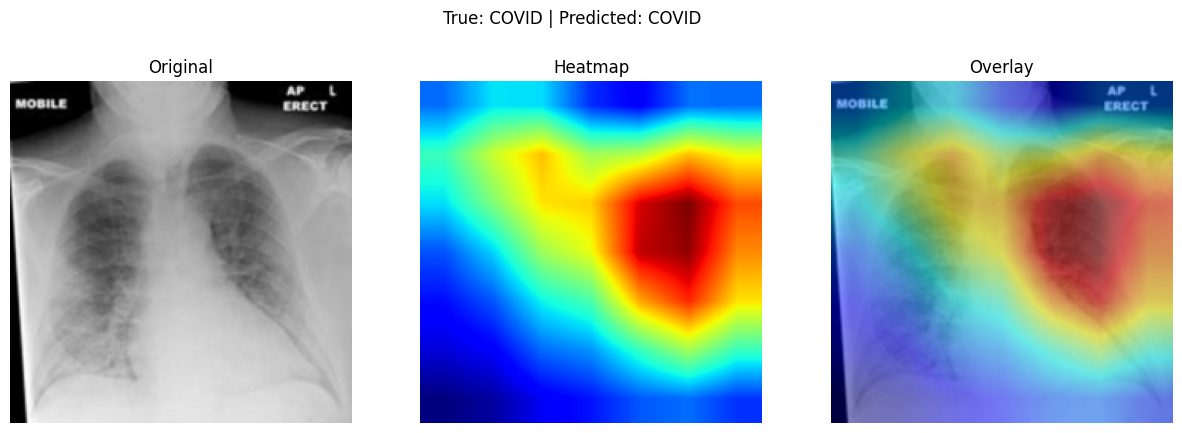

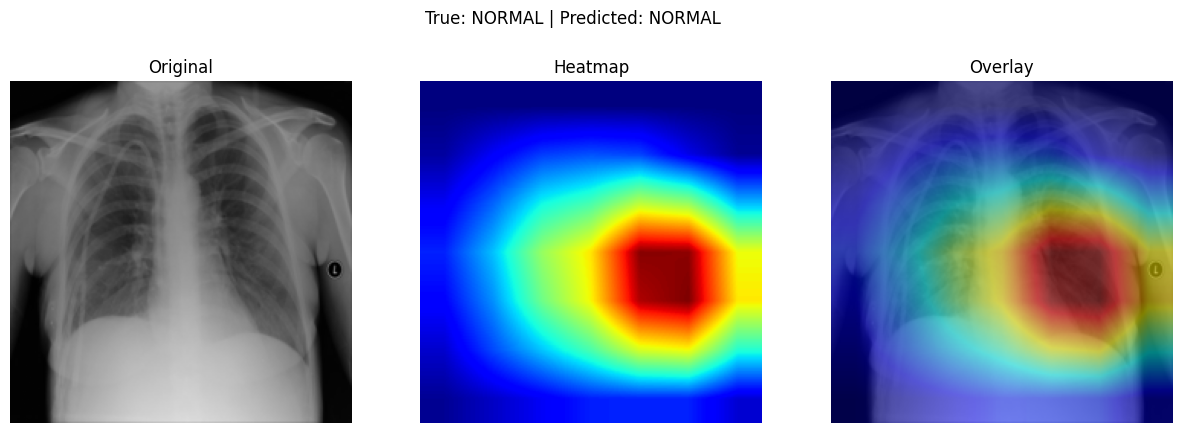

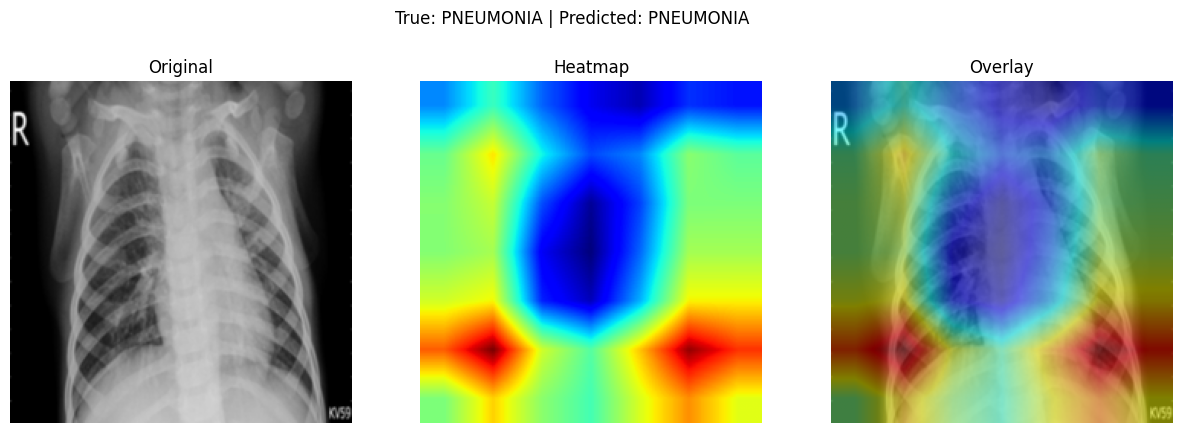

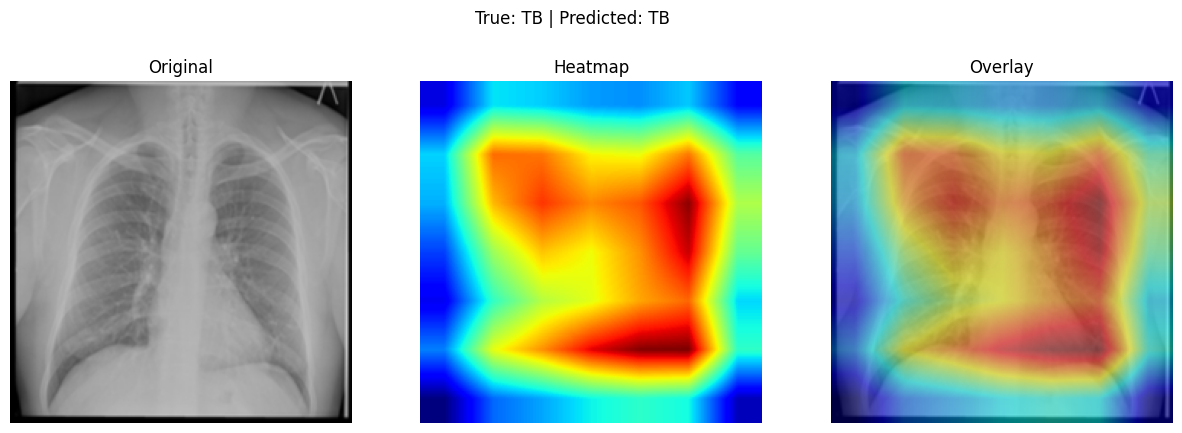

misclassified: 13 of 600


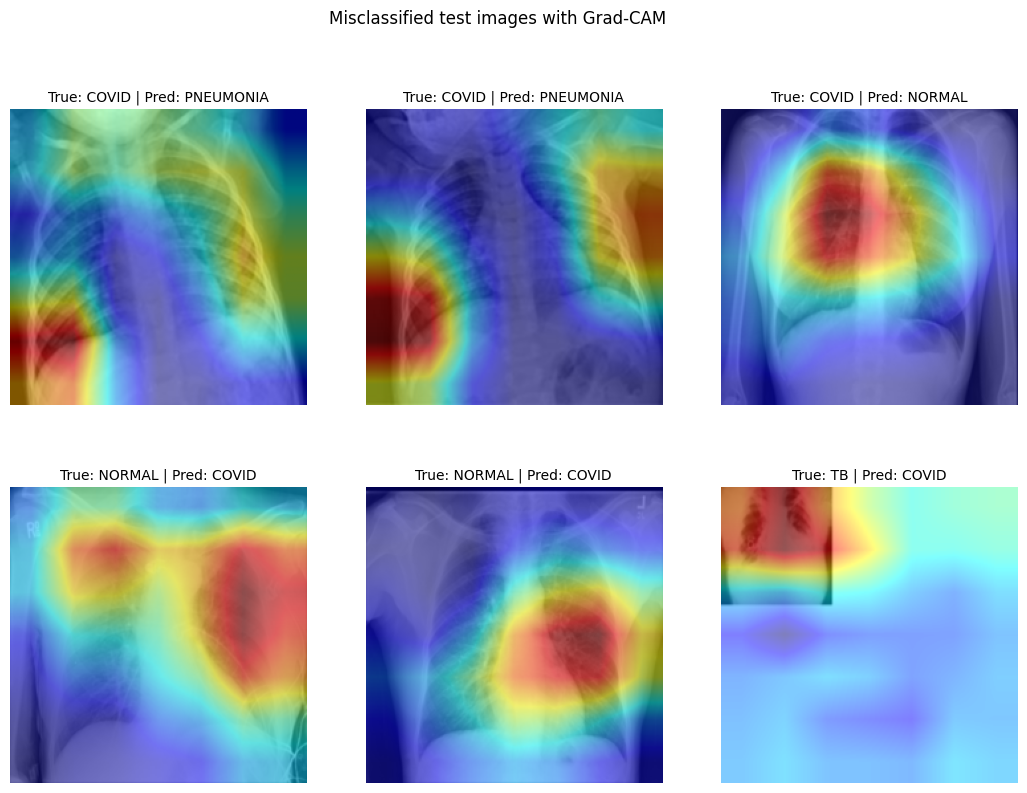

saved to /content/drive/MyDrive/chest_xray_cnn


In [1]:
import sys
for name in [m for m in sys.modules if m.startswith("xray_classifier")]:
    del sys.modules[name]

%cd /content
!rm -rf chest-xray-cnn-gradcam
!git clone -q https://github.com/paulblessingjeremiah-ai/chest-xray-cnn-gradcam.git
%cd chest-xray-cnn-gradcam
!pip install -q -r requirements.txt

import os, shutil
import cv2
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
sys.path.insert(0, "/content/chest-xray-cnn-gradcam/src")

from google.colab import drive
drive.mount('/content/drive')

dst = "/content/xray_data"
if not os.path.exists(dst):
    shutil.copytree("/content/drive/MyDrive/MedBench_Project/data/raw/aminu_kano_cxr", dst)

from xray_classifier.data import get_dataloaders
from xray_classifier.model import build_model
from xray_classifier.train import evaluate
from xray_classifier.gradcam import GradCAM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader, val_loader, test_loader, class_names = get_dataloaders(
    f"{dst}/train_folder", f"{dst}/test_folder"
)
print("train / val / test:", len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset))

model = build_model(num_classes=4).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/chest_xray_cnn/best_model.pt", map_location=device))
model.eval()

criterion = nn.CrossEntropyLoss()
print("val accuracy: ", evaluate(model, val_loader, criterion, device)[1])
print("test accuracy:", evaluate(model, test_loader, criterion, device)[1])

test_ds = test_loader.dataset
grad_cam = GradCAM(model, model.layer4[-1])


def explain(idx):
    """Return the display image, heatmap, overlay, true label and predicted label for one test image."""
    image, label = test_ds[idx]
    cam, pred = grad_cam.generate(image.unsqueeze(0).to(device))
    img = (image.permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
    heat = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB) / 255.0
    return img, cam, 0.5 * img + 0.5 * heat, label, pred


# One example per class, same 3-panel layout as before
first_of_class = {}
for i, label in enumerate(test_ds.targets):
    first_of_class.setdefault(label, i)

os.makedirs("gradcam_examples", exist_ok=True)
for cls in range(4):
    img, cam, overlay, label, pred = explain(first_of_class[cls])
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img); axes[0].set_title("Original")
    axes[1].imshow(cam, cmap="jet"); axes[1].set_title("Heatmap")
    axes[2].imshow(overlay); axes[2].set_title("Overlay")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(f"True: {class_names[label]} | Predicted: {class_names[pred]}")
    plt.savefig(f"gradcam_examples/{class_names[label]}.png", bbox_inches="tight")
    plt.show()

# The model's mistakes
wrong = []
with torch.no_grad():
    for i in range(len(test_ds)):
        image, label = test_ds[i]
        if model(image.unsqueeze(0).to(device)).argmax(1).item() != label:
            wrong.append(i)
print("misclassified:", len(wrong), "of", len(test_ds))

chosen = wrong[::max(1, len(wrong) // 6)][:6]
fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, idx in zip(axes.ravel(), chosen):
    _, _, overlay, label, pred = explain(idx)
    ax.imshow(overlay)
    ax.set_title(f"True: {class_names[label]} | Pred: {class_names[pred]}", fontsize=10)
    ax.axis("off")
for ax in axes.ravel()[len(chosen):]:
    ax.axis("off")
plt.suptitle("Misclassified test images with Grad-CAM")
plt.savefig("gradcam_errors.png", bbox_inches="tight")
plt.show()

out = "/content/drive/MyDrive/chest_xray_cnn"
shutil.copytree("gradcam_examples", f"{out}/gradcam_examples", dirs_exist_ok=True)
shutil.copy("gradcam_errors.png", f"{out}/gradcam_errors.png")
print("saved to", out)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

from PIL import Image

folder = "/content/drive/MyDrive/chest_xray_cnn/gradcam_examples"
names = ["COVID", "NORMAL", "PNEUMONIA", "TB"]
imgs = [Image.open(f"{folder}/{n}.png").convert("RGB") for n in names]

width = 1000
resized = [im.resize((width, int(im.height * width / im.width))) for im in imgs]
sheet = Image.new("RGB", (width, sum(im.height for im in resized)), "white")
y = 0
for im in resized:
    sheet.paste(im, (0, y))
    y += im.height

sheet.save("/content/drive/MyDrive/chest_xray_cnn/class_sheet.png")
print("saved", sheet.size)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
saved (1000, 1464)


In [3]:
import os
import cv2
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

root = "/content/xray_data/train_folder"
classes = sorted(os.listdir(root))
X, y = [], []
for label, cls in enumerate(classes):
    for f in os.listdir(f"{root}/{cls}"):
        img = cv2.imread(f"{root}/{cls}/{f}", cv2.IMREAD_GRAYSCALE)
        h, w = img.shape
        X.append([h, w, w / h, img.mean(), img.std(), (img < 10).mean(), (img > 245).mean()])
        y.append(label)
X, y = np.array(X), np.array(y)

print("columns: height, width, aspect, mean, std, share black, share white")
for label, cls in enumerate(classes):
    print(f"{cls:<10}", X[y == label].mean(axis=0).round(2))

for name, cols in [("size and shape only", [0, 1, 2]),
                   ("brightness and borders only", [3, 4, 5, 6]),
                   ("all seven", list(range(7)))]:
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    acc = cross_val_score(clf, X[:, cols], y, cv=5).mean()
    print(f"{name}: {acc:.3f}  (chance = 0.25)")

columns: height, width, aspect, mean, std, share black, share white
COVID      [2.9900e+02 2.9900e+02 1.0000e+00 1.4394e+02 5.6100e+01 4.0000e-02
 3.0000e-02]
NORMAL     [5.1200e+02 5.1200e+02 1.0000e+00 1.2988e+02 6.1800e+01 6.0000e-02
 0.0000e+00]
PNEUMONIA  [2.9900e+02 2.9900e+02 1.0000e+00 1.2497e+02 5.7660e+01 7.0000e-02
 0.0000e+00]
TB         [5.1200e+02 5.1200e+02 1.0000e+00 1.2992e+02 5.1660e+01 4.0000e-02
 2.0000e-02]
size and shape only: 0.500  (chance = 0.25)
brightness and borders only: 0.544  (chance = 0.25)
all seven: 0.812  (chance = 0.25)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


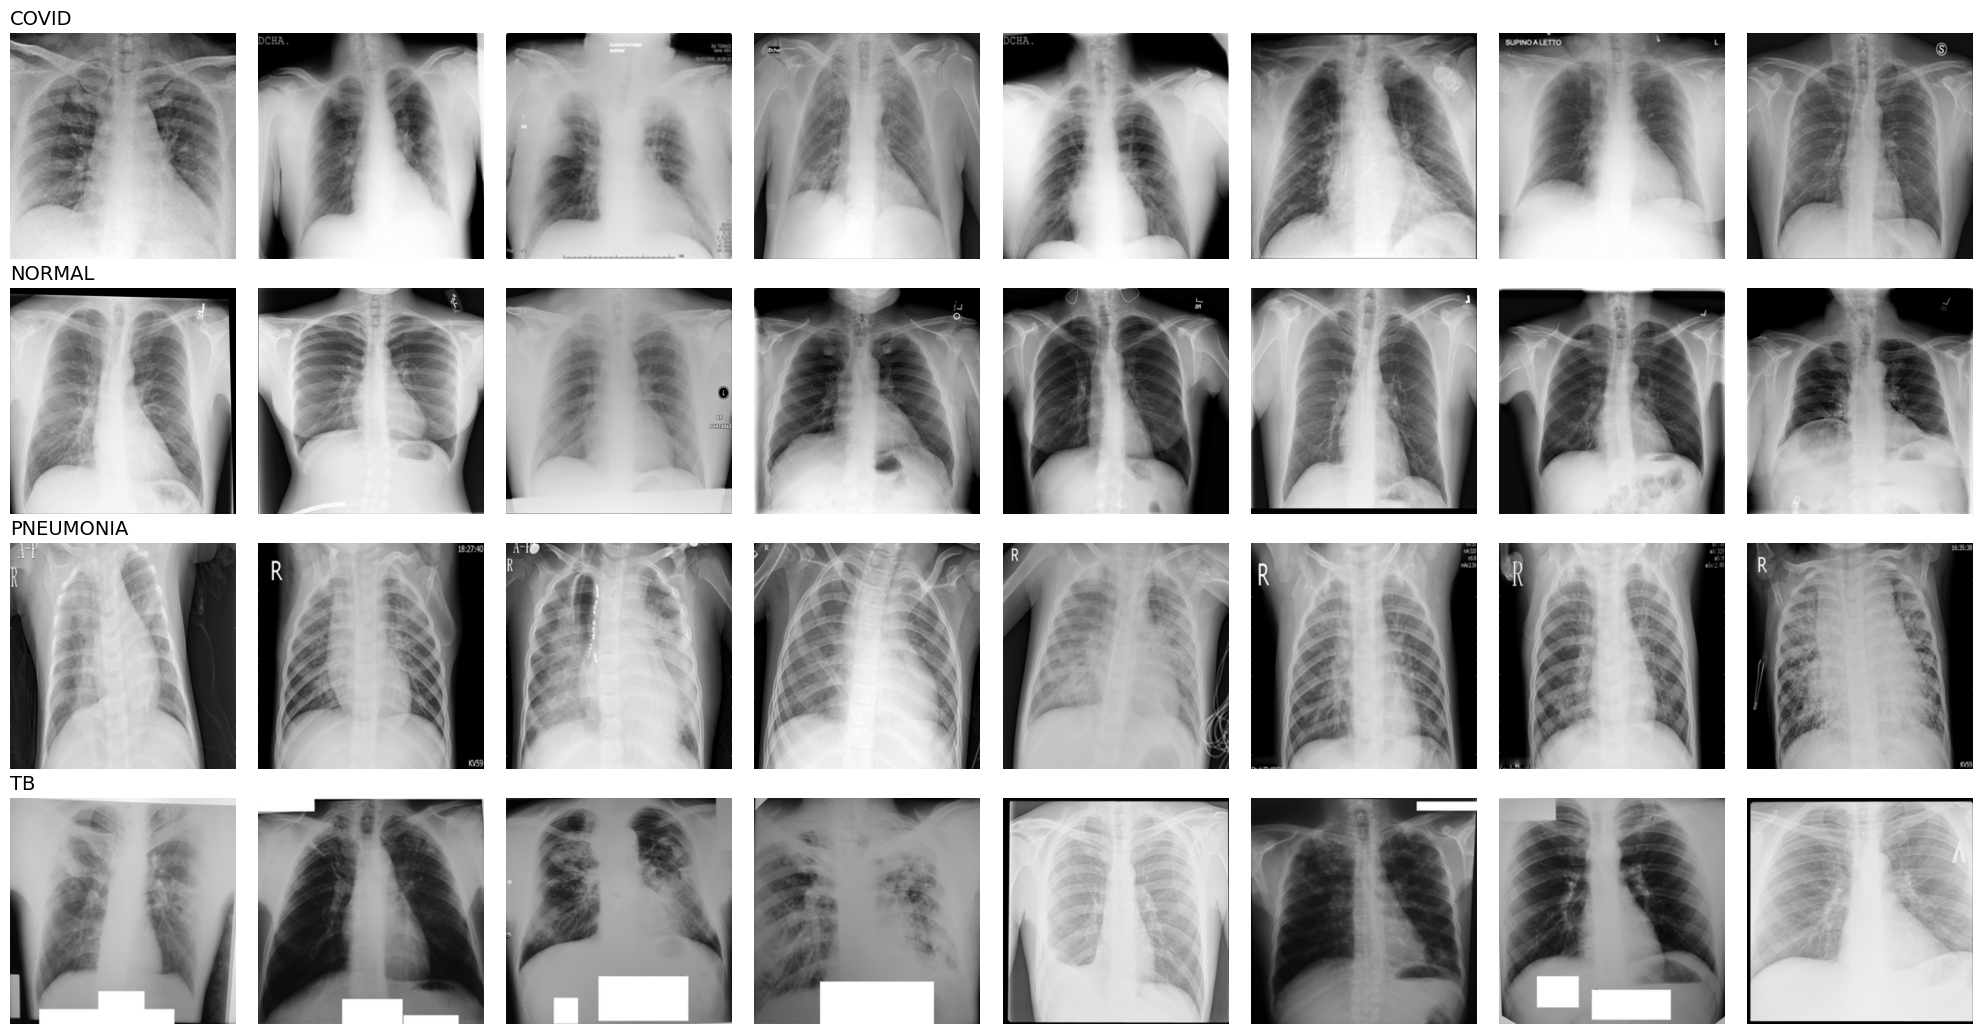

In [4]:
import os, random, shutil
import cv2
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

dst = "/content/xray_data"
if not os.path.exists(dst):
    shutil.copytree("/content/drive/MyDrive/MedBench_Project/data/raw/aminu_kano_cxr", dst)

root = f"{dst}/train_folder"
classes = sorted(os.listdir(root))
random.seed(1)

fig, axes = plt.subplots(len(classes), 8, figsize=(20, 2.6 * len(classes)))
for r, cls in enumerate(classes):
    files = random.sample(os.listdir(f"{root}/{cls}"), 8)
    for c, f in enumerate(files):
        img = cv2.imread(f"{root}/{cls}/{f}", cv2.IMREAD_GRAYSCALE)
        axes[r, c].imshow(img, cmap="gray")
        axes[r, c].axis("off")
        if c == 0:
            axes[r, c].set_title(cls, loc="left", fontsize=14)
plt.tight_layout()

os.makedirs("/content/drive/MyDrive/chest_xray_cnn", exist_ok=True)
plt.savefig("/content/drive/MyDrive/chest_xray_cnn/contact_sheet.png", dpi=80)
plt.show()

/content
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
share of the image called lung (train): mean | 5th percentile | 95th percentile
COVID      0.317 | 0.184 | 0.482
NORMAL     0.327 | 0.236 | 0.429
PNEUMONIA  0.296 | 0.180 | 0.393
TB         0.435 | 0.289 | 0.588


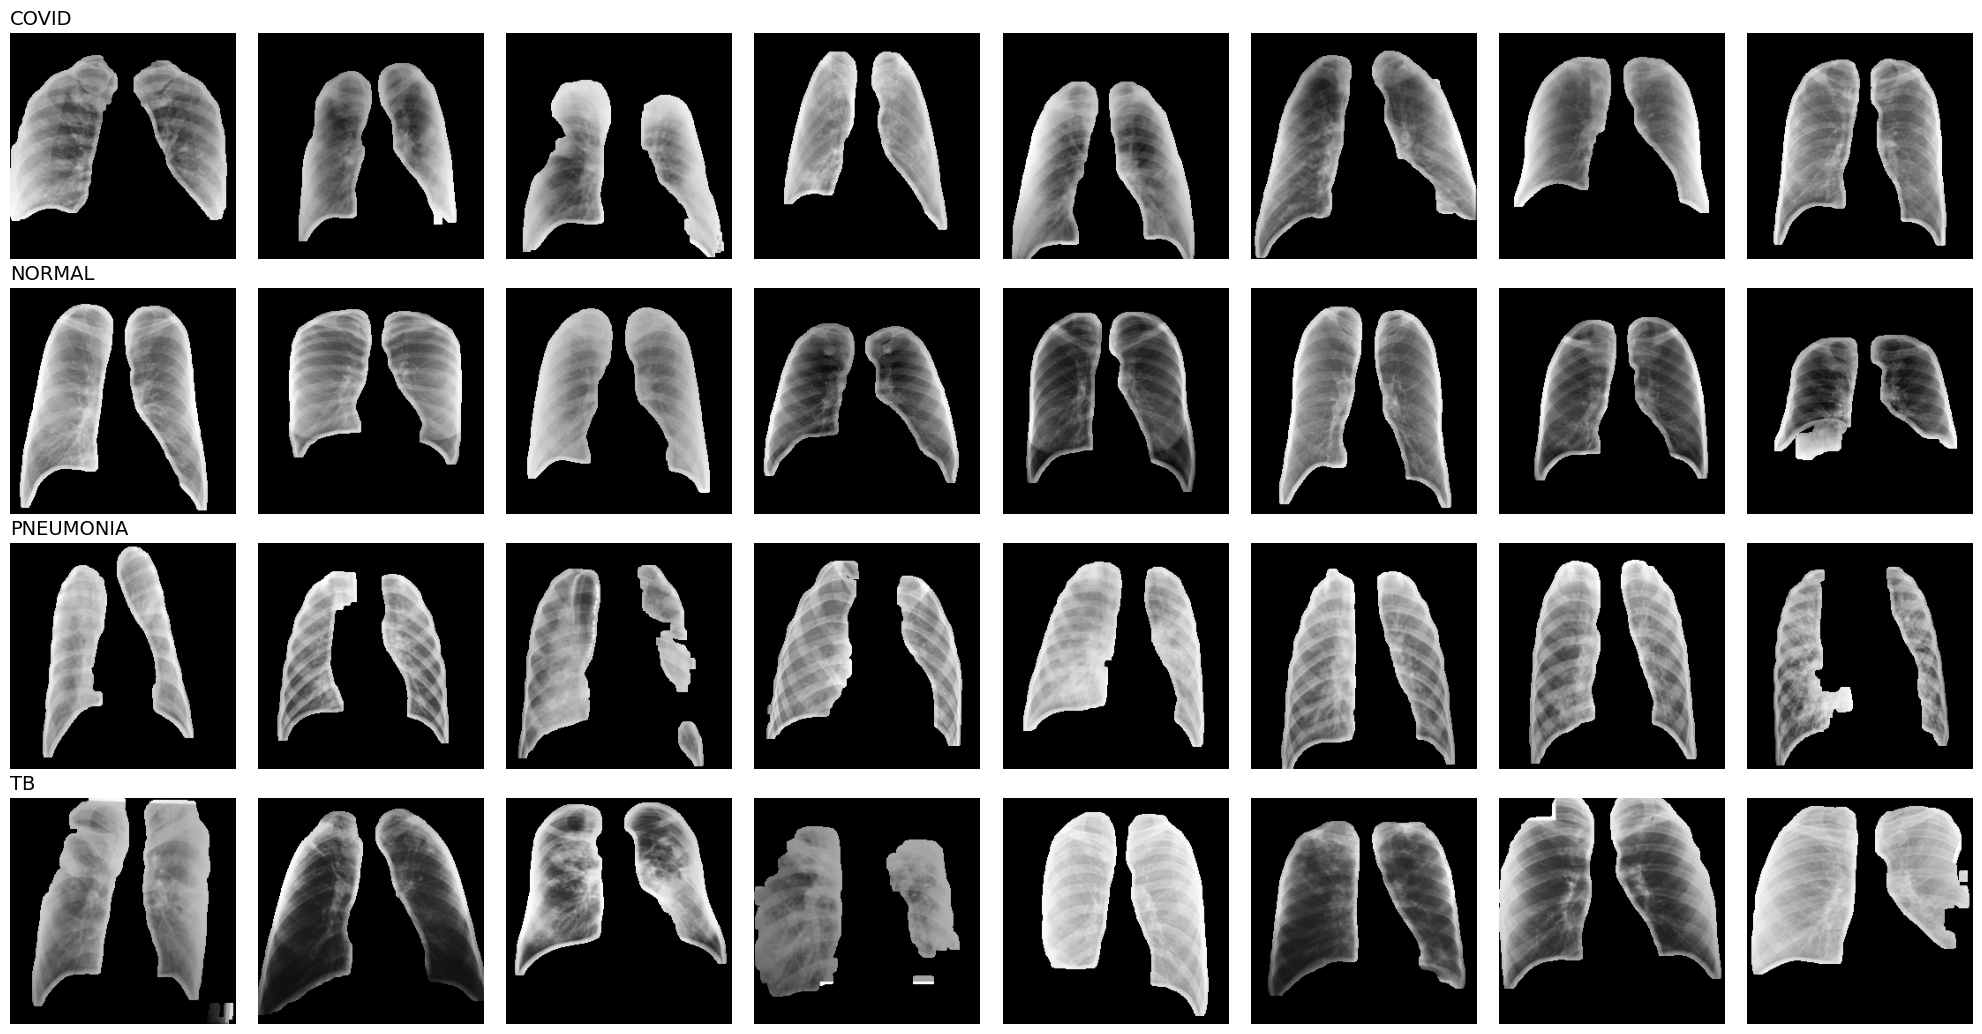

saved to /content/drive/MyDrive/chest_xray_cnn


In [5]:
import sys
for name in [m for m in sys.modules if m.startswith(("lung_seg", "xray_classifier"))]:
    del sys.modules[name]

%cd /content
!rm -rf lung-segmentation-unet
!git clone -q https://github.com/paulblessingjeremiah-ai/lung-segmentation-unet.git
!pip install -q -r /content/lung-segmentation-unet/requirements.txt

import os, shutil, random
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
sys.path.insert(0, "/content/lung-segmentation-unet/src")

from google.colab import drive
drive.mount('/content/drive')

from lung_seg.model import UNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
unet = UNet().to(device)
unet.load_state_dict(torch.load("/content/drive/MyDrive/lung_seg_data/best_unet.pt", map_location=device))
unet.eval()

dst = "/content/xray_data"
if not os.path.exists(dst):
    shutil.copytree("/content/drive/MyDrive/MedBench_Project/data/raw/aminu_kano_cxr", dst)

out_root = "/content/xray_masked"
shutil.rmtree(out_root, ignore_errors=True)
SIZE = 256
kernel = np.ones((5, 5), np.uint8)   # small dilation so the lung edges are not cut
fractions = {}

for split in ["train_folder", "test_folder"]:
    for cls in sorted(os.listdir(f"{dst}/{split}")):
        os.makedirs(f"{out_root}/{split}/{cls}", exist_ok=True)
        files = sorted(os.listdir(f"{dst}/{split}/{cls}"))
        fractions[(split, cls)] = []
        for start in range(0, len(files), 32):
            batch_files = files[start:start + 32]
            imgs = []
            for f in batch_files:
                img = cv2.imread(f"{dst}/{split}/{cls}/{f}", cv2.IMREAD_GRAYSCALE)
                imgs.append(cv2.resize(img, (SIZE, SIZE), interpolation=cv2.INTER_AREA))
            x = torch.from_numpy(np.stack(imgs).astype(np.float32) / 255.0).unsqueeze(1).to(device)
            with torch.no_grad():
                masks = (torch.sigmoid(unet(x)) > 0.5).cpu().numpy()[:, 0].astype(np.uint8)
            for f, img, mask in zip(batch_files, imgs, masks):
                mask = cv2.dilate(mask, kernel, iterations=2)
                fractions[(split, cls)].append(mask.mean())
                cv2.imwrite(f"{out_root}/{split}/{cls}/{os.path.splitext(f)[0]}.png", img * mask)

classes = sorted(os.listdir(f"{dst}/train_folder"))
print("share of the image called lung (train): mean | 5th percentile | 95th percentile")
for cls in classes:
    arr = np.array(fractions[("train_folder", cls)])
    print(f"{cls:<10} {arr.mean():.3f} | {np.percentile(arr, 5):.3f} | {np.percentile(arr, 95):.3f}")

# Contact sheet of masked images, 8 random per class
random.seed(1)
fig, axes = plt.subplots(len(classes), 8, figsize=(20, 2.6 * len(classes)))
for r, cls in enumerate(classes):
    files = random.sample(os.listdir(f"{out_root}/train_folder/{cls}"), 8)
    for c, f in enumerate(files):
        axes[r, c].imshow(cv2.imread(f"{out_root}/train_folder/{cls}/{f}", cv2.IMREAD_GRAYSCALE), cmap="gray")
        axes[r, c].axis("off")
        if c == 0:
            axes[r, c].set_title(cls, loc="left", fontsize=14)
plt.tight_layout()

keep = "/content/drive/MyDrive/chest_xray_cnn"
os.makedirs(keep, exist_ok=True)
plt.savefig(f"{keep}/masked_contact_sheet.png", dpi=80)
plt.show()
shutil.copytree(out_root, f"{keep}/masked_data", dirs_exist_ok=True)
print("saved to", keep)

In [6]:
import sys
for name in [m for m in sys.modules if m.startswith("xray_classifier")]:
    del sys.modules[name]

%cd /content
!rm -rf chest-xray-cnn-gradcam
!git clone -q https://github.com/paulblessingjeremiah-ai/chest-xray-cnn-gradcam.git
!pip install -q -r /content/chest-xray-cnn-gradcam/requirements.txt
sys.path.insert(0, "/content/chest-xray-cnn-gradcam/src")

import os, io, json, shutil, contextlib
import numpy as np
import torch
import torch.nn as nn

from google.colab import drive
drive.mount('/content/drive')
keep = "/content/drive/MyDrive/chest_xray_cnn"

orig = "/content/xray_data"
if not os.path.exists(orig):
    shutil.copytree("/content/drive/MyDrive/MedBench_Project/data/raw/aminu_kano_cxr", orig)
masked = "/content/xray_masked"
if not os.path.exists(masked):
    shutil.copytree(f"{keep}/masked_data", masked)

from xray_classifier.data import get_dataloaders
from xray_classifier.model import build_model
from xray_classifier.train import train_model, evaluate

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


def run(root, seed):
    torch.manual_seed(seed)
    train_loader, val_loader, test_loader, _ = get_dataloaders(f"{root}/train_folder", f"{root}/test_folder")
    model = build_model(num_classes=4).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    ckpt = f"/content/tmp_{os.path.basename(root)}_{seed}.pt"
    with contextlib.redirect_stdout(io.StringIO()):
        best_val = train_model(model, train_loader, val_loader, criterion, optimizer, device,
                               num_epochs=10, checkpoint_path=ckpt)
    model.load_state_dict(torch.load(ckpt, map_location=device))
    test_acc = evaluate(model, test_loader, criterion, device)[1]
    return best_val, test_acc


results = {"original": [], "lung_masked": []}
for seed in [0, 1, 2]:
    for name, root in [("original", orig), ("lung_masked", masked)]:
        val_acc, test_acc = run(root, seed)
        results[name].append((seed, val_acc, test_acc))
        print(f"seed {seed} | {name:<11} | best val {val_acc:.4f} | test {test_acc:.4f}")
        with open(f"{keep}/masking_results.json", "w") as fh:
            json.dump(results, fh)

print()
for name, rows in results.items():
    t = np.array([r[2] for r in rows])
    print(f"{name:<11} test accuracy: mean {t.mean():.4f}, std {t.std():.4f}, runs {np.round(t, 4).tolist()}")

/content
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device: cuda
seed 0 | original    | best val 0.9933 | test 0.9733
seed 0 | lung_masked | best val 0.9700 | test 0.9400
seed 1 | original    | best val 0.9933 | test 0.9833
seed 1 | lung_masked | best val 0.9600 | test 0.9283
seed 2 | original    | best val 0.9933 | test 0.9850
seed 2 | lung_masked | best val 0.9767 | test 0.9350

original    test accuracy: mean 0.9806, std 0.0052, runs [0.9733, 0.9833, 0.985]
lung_masked test accuracy: mean 0.9344, std 0.0048, runs [0.94, 0.9283, 0.935]
